# Exercise 2

1

In [52]:
import numpy as np
x = np.random.rand(100,1)
y = 2.0+5*x*x+0.1*np.random.randn(100,1)

X = np.zeros((100,3))

for j in range(3):
    X[:,j] = x.flatten()**j

#print(x)


In [ ]:
theta = np.linalg.inv(X.T @ X) @ X.T @ y
y_tilde = X @ theta

#print(y_tilde)

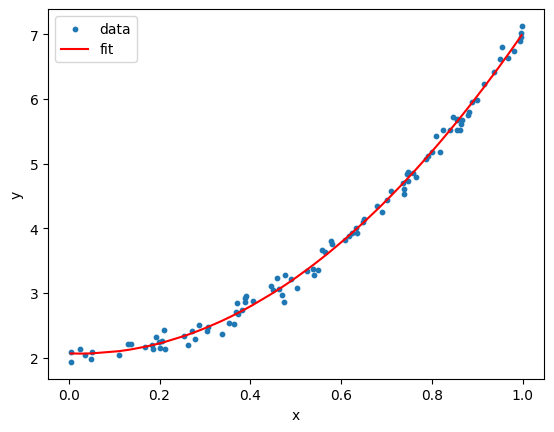

In [54]:
import matplotlib.pyplot as plt

x_sorted_idx = np.argsort(x.flatten())
plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde.flatten()[x_sorted_idx], color="red", label="fit")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [55]:
mse = np.mean((y - y_tilde)**2)
print("MSE:", mse)

MSE: 0.010574845678128265


2

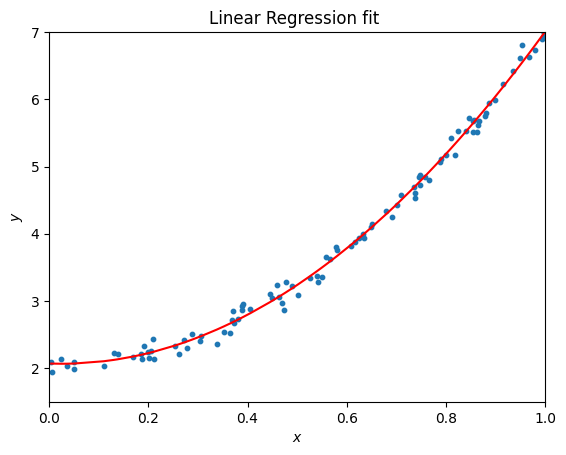

In [ ]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X,y)
ypredict = linreg.predict(X)


plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], ypredict.flatten()[x_sorted_idx],'r-')
plt.axis([0.0,1.0,1.5, 7.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Linear Regression fit ')
plt.show()

3.

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error                               
print("Mean squared error:", mean_squared_error(y, ypredict))
# Explained variance score: 1 is perfect prediction                                 
print('Variance score:', r2_score(y, ypredict))

Mean squared error: 0.01057484567812826
Variance score: 0.9954618604226237


The intercept alpha: 
 [2.06855672]
Coefficient beta : 
 [[ 0.         -0.26542602  5.20506376]]


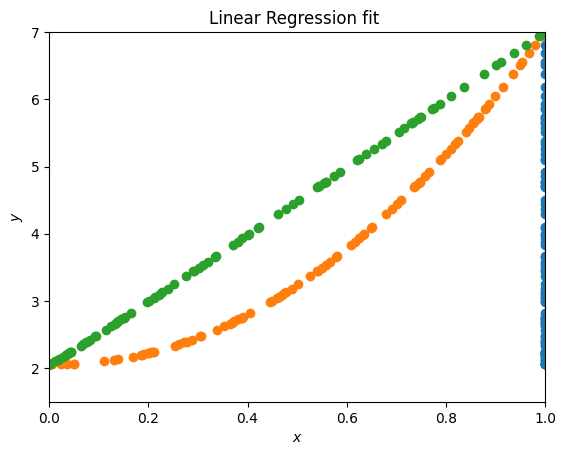

In [74]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_error

linreg = LinearRegression()
linreg.fit(X,y)
ypredict = linreg.predict(X)

print('The intercept alpha: \n', linreg.intercept_)
print('Coefficient beta : \n', linreg.coef_)

# Mean squared log error                                                        
#print('Mean squared log error: %.2f' % mean_squared_log_error(y, ypredict) )
# Mean absolute error                                                           
#print('Mean absolute error: %.2f' % mean_absolute_error(y, ypredict))

plt.plot(X, ypredict, "o")
#plt.plot(X, y ,'ro')
plt.axis([0.0,1.0,1.5, 7.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Linear Regression fit ')
plt.show()

# Exercise 3

a)

In [3]:
import numpy as np

np.random.seed()
n = 100
# Make data set.
x3 = np.linspace(-3, 3, n).reshape(-1, 1)
y3 = np.exp(-x3**2) + 1.5 * np.exp(-(x3-2)**2)+ np.random.normal(0, 0.1, x3.shape)

X3 = np.zeros((n,6))

for j in range(6):
    X3[:,j] = x3.flatten()**j

#print(X3)

from sklearn.model_selection import train_test_split

X3_train, X3_test, y3_train, y3_test, x3_train, x3_test = train_test_split(X3, y3, x3, test_size=0.33, random_state=42)

print(np.shape(X3_train), np.shape(X3_test))

(67, 6) (33, 6)


b)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

OLS = LinearRegression()
OLS.fit(X3_train,y3_train) # fitting a model on the training data

ypredict_train = OLS.predict(X3_train)
ypredict_test = OLS.predict(X3_test)

print("Mean squared error for training data:", mean_squared_error(y3_train, ypredict_train))
print("Mean squared error for test data:", mean_squared_error(y3_test, ypredict_test))



Mean squared error for training data: 0.02327513956499945
Mean squared error for test data: 0.023318990446047887


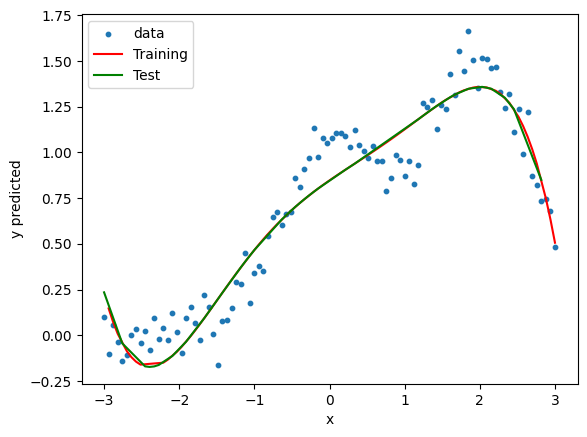

In [9]:
import matplotlib.pyplot as plt

x3_train_idx = np.argsort(x3_train.flatten())
x3_test_idx = np.argsort(x3_test.flatten())

plt.scatter(x3, y3, s=10, label="data")
plt.plot(x3_train.flatten()[x3_train_idx], ypredict_train.flatten()[x3_train_idx], color="red", label="Training")
plt.plot(x3_test.flatten()[x3_test_idx], ypredict_test.flatten()[x3_test_idx], color="green", label="Test")
plt.legend()
plt.xlabel("x")
plt.ylabel("y predicted")
plt.show()

c)

In [34]:
def model_poly(x,y,degree):
    n = len(x)
    X = np.zeros((n,degree+1))
    for j in range(degree+1):
        X[:,j] = x.flatten()**j

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

    OLS = LinearRegression()
    OLS.fit(X_train,y_train) 

    y_predict_train = OLS.predict(X_train)
    y_predict_test = OLS.predict(X_test)

    mse_train = mean_squared_error(y_train, y_predict_train)
    mse_test = mean_squared_error(y_test, y_predict_test)

    return mse_train, mse_test

    

In [35]:
print(model_poly(x3,y3,4))
print(model_poly(x3,y3,8))

(0.03064967901358541, 0.025225421201695877)
(0.007968899178427474, 0.012657033519760434)


In [36]:
degrees = np.arange(0,16)
mse_train_array = np.zeros(len(degrees))
mse_test_array = np.zeros(len(degrees))


for i in degrees:
    mse_train_array[i], mse_test_array[i] = model_poly(x3,y3,i)

print(mse_train_array)

[0.26632217 0.08286946 0.05603445 0.03092369 0.03064968 0.02327514
 0.01711304 0.01357922 0.0079689  0.0076051  0.00624278 0.00623643
 0.00922547 0.02030746 0.04180671 0.06549708]


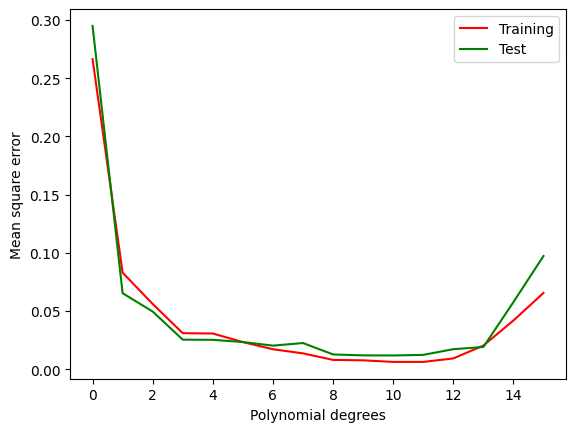

In [38]:
plt.plot(degrees, mse_train_array, color="red", label="Training")
plt.plot(degrees, mse_test_array, color="green", label="Test")
plt.xlabel("Polynomial degrees")
plt.ylabel("Mean square error")
plt.legend()
plt.show()

In [ ]:
min_index_train = np.where(mse_train_array == min(mse_train_array))
print(f'the optimal polynomial degree for training data is:', min_index_train[0][0])

min_index_test = np.where(mse_test_array == min(mse_test_array))
print(f'the optimal polynomial degree for test data is:',min_index_test[0][0])


the optimal polynomial degree for training data is: 11
the optimal polynomial degree for test data is: 10
